In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 



clientes = "../data/clientes.csv"
df = pd.read_csv(clientes)


## **Initial Data Inspection**

In [7]:
print("Dataset Dimention (Columns, Rows):", df.shape)

Dataset Dimention (Columns, Rows): (1143, 13)


In [8]:
print(df.columns)


Index(['customer_id', 'country_or_region', 'commercial_region', 'island',
       'municipality', 'city', 'postal_area', 'postal_code', 'street',
       'address', 'customer_type', 'company_name', 'customer_since_year'],
      dtype='str')


*Shows the columns* 

In [9]:
df.head()

,customer_id,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,customer_type,company_name,customer_since_year
0,842570,Country CT11: Land of The Final Version,Region RG37: We Will See Later,NaN,NaN,City CY417: Missing Cell Port,NaN,Postal code PC828: #REF! Delivery Route,NaN,Address AD1120: Cell Without a Home,NaN,Excel Is Not A Database Ltd 150,2018
1,770941,Country CT9: Land of The Final Version,NaN,NaN,NaN,NaN,NaN,Postal code PC56: #REF! Delivery Route,NaN,Address AD62: Cell Without a Home,NaN,Excel Is Not A Database Ltd 1064,2021
2,827053,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS2: The Pivot Archipelago,Municipality MU14: Council of Last Minute Edits,NaN,Postal area PA271: Hidden Sheet Sector,Postal code PC827: #REF! Delivery Route,Street ST170: PowerPoint New Walk,Address AD449: Cell Without a Home,NaN,Excel Is Not A Database Ltd 113,2016
3,494648,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS2: The Pivot Archipelago,Municipality MU14: Council of Last Minute Edits,NaN,Postal area PA271: Hidden Sheet Sector,Postal code PC826: #REF! Delivery Route,NaN,Address AD454: Cell Without a Home,NaN,Excel Is Not A Database Ltd 430,2015
4,429291,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS2: The Pivot Archipelago,Municipality MU14: Council of Last Minute Edits,NaN,Postal area PA271: Hidden Sheet Sector,Postal code PC826: #REF! Delivery Route,NaN,Address AD453: Cell Without a Home,NaN,Excel Is Not A Database Ltd 673,2015



*Gives the first five rows of the dataset*<br>
After analysing the first five rows we can already see that we have some missing values(NaN)


In [10]:
print("\n--- Datatype Information ---")
df.info()


--- Datatype Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          1143 non-null   int64  
 1   country_or_region    1143 non-null   str    
 2   commercial_region    1029 non-null   str    
 3   island               565 non-null    str    
 4   municipality         984 non-null    str    
 5   city                 597 non-null    str    
 6   postal_area          1072 non-null   str    
 7   postal_code          973 non-null    str    
 8   street               545 non-null    str    
 9   address              1137 non-null   str    
 10  customer_type        0 non-null      float64
 11  company_name         1143 non-null   str    
 12  customer_since_year  1143 non-null   int64  
dtypes: float64(1), int64(2), str(10)
memory usage: 116.2 KB


**1.** This  line of code give us the total number of entries of the dataset as well as the total number of columns and their respective index and the data type(Dtype) of each column, we can also see the number of values which are not null for each variable(column).<br>

**2.** Inconsistency: We found an inconsistency in the data type of the variable(customer_type), because this variable represents the type of a costumer and it's type cannot be represented by a float. 


## **Descriptive Statistics**

In [11]:
df.describe(include ="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1143.0,NaN,NaN,NaN,553917.786527,259693.430653,103940.0,323855.5,555330.0,782527.5,998870.0
country_or_region,1143,11,Country CT10: Land of The Final Version,1079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commercial_region,1029,37,Region RG17: We Will See Later,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,565,10,Island IS7: The Pivot Archipelago,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipality,984,183,Municipality MU1: Council of Last Minute Edits,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,597,417,City CY194: PowerPoint New Hills,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postal_area,1072,271,Postal area PA259: Hidden Sheet Sector,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
postal_code,973,828,Postal code PC545: #REF! Delivery Route,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,545,511,Street ST192: Last Save Walk,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,1137,1120,Address AD489: Cell Without a Home,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*After looking for the content in the table we can see that we have a lot of NaN values. This occurs because since is not possible for some columns to calculate their values due to their type being numerical and the value they calculate being ordinal and vice-versa .*<br>
So to solve this issue we did the code below:

In [12]:
df["customer_id"] = df["customer_id"].astype(str)

# Numeric variables
display(df.describe().T)

# Categorical variables
display(df.describe(exclude="number").T)

,count,mean,std,min,25%,50%,75%,max
customer_type,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_since_year,1143.0,2016.999125,2.971405,2015.0,2015.0,2015.0,2018.0,2026.0


,count,unique,top,freq
customer_id,1143,1143,842570,1
country_or_region,1143,11,Country CT10: Land of The Final Version,1079
commercial_region,1029,37,Region RG17: We Will See Later,519
island,565,10,Island IS7: The Pivot Archipelago,133
municipality,984,183,Municipality MU1: Council of Last Minute Edits,58
city,597,417,City CY194: PowerPoint New Hills,14
postal_area,1072,271,Postal area PA259: Hidden Sheet Sector,57
postal_code,973,828,Postal code PC545: #REF! Delivery Route,6
street,545,511,Street ST192: Last Save Walk,5
address,1137,1120,Address AD489: Cell Without a Home,3


After running the lines of code above, we can observe that the customer table contains 1143 customers and 13 variables . Each customer has one unique identifier(customer_id) so the table can be joined to the train.csv without duplicating rows. 

 ### *Numerical Variables:* 
**1.** **Customer_since_year**: By looking at the min and max values(they range between 2015-2026), we can see that the oldest client is from 2015 and the newest client is from 2026 respectively.<br>
**Note:** *Since the 2026 year is still going the number of costumers will  probably still increase.* <br>
 **2.** **Customer_type**: The variable customer_type is empty (all the values are NaN, it doesn't contain any information), so it might be removed later.

 ### *Categorical Variables:* 
**1.** **Customer_id**: Unique identifier of each customer (1143 unique values, no missing values and no duplicates). It is not a descriptive variable but the key used to join this table with train.csv/test.csv, so by itself it has no predictive meaning.<br>
**2.** **country_or_region**: This variable is highly unbalanced 94% of the values correspond to the same country/region(for example, CT10).<br>
**3.** **commercial_region:** *(37  unique categories)* is also concentrated, with RG17 covering 50% of the non-missing values. <br>
**4.** **island:** *(10 unique categories)* Appears only for 565 costumers,all from CT10, which suggests us that missing values could mean that the costumers are from mainland(might be better to create a new category named 'mainland') rather than an error recording the value. <br>
**5.** **municipality:** *(183 unique categories)* 159 missing values (13.9%). The most frequent municipality (MU1) has 58 customers, 65 municipalities have only one customer and the top 10 cover about 40% of the non-missing values.<br>
**6.** **city:** *(417 unique categories)* 546 missing values (47.8%), almost half of the customers. 360 cities appear only once (the most frequent one has only 14 customers), so the variable is very fragmented.<br>
**7.** **postal_area:** *(271 unique categories)* Only 71 missing values (6.2%), the most complete geographic variable after country_or_region. The most frequent area (PA259) has 57 customers and 126 areas appear only once.<br>
**8.** **postal_code:** *(828 unique categories)* 170 missing values (14.9%). 721 postal codes appear only once (maximum of 6 customers per code), so it behaves almost like an identifier.<br>
**9.** **street:** *(511 unique categories)* 598 missing values (52.3%), more than half of the customers. 485 streets appear only once (maximum of 5 customers per street).<br>
**10.** **adress:** *(1120 unique categories)* Only 6 missing values, and at most 3 customers share the same address. This means that there are few costumers per household(normally is only one buyer per household)<br>
**11.** **company_name:** No missing values and 1141 unique values for 1143 customers: only two names are repeated (Ltd 384 and Ltd 664, two customers each). <br>

**Note:** *postal_code, street, address and company_name are (almost) unique per customer, so they behave like identifiers and must be treated critically later (feature selection).*

**Note:**
*Because the customer_id variable has only unique values(they are all different) we can not compute the columns,like mean,std,...,. to solve this we converted the variable to a string, so that it can be grouped in the table with the categoric values. The column top for the customer_id inffers the first recorded value in the dataset instead of the most frequent one.*


## **Data Quality**
*Check the completeness, uniqueness and consistency of the customer table before exploring it. The problems found here are only identified; they are handled in the pre-processing step.*

### *Missing Values*
*Number and percentage of missing values per column.*

In [6]:
# Number and percentage of missing values per column
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1)
}).sort_values("n_missing", ascending=False)
missing

,n_missing,pct_missing
customer_type,1143,100.0
street,598,52.3
island,578,50.6
city,546,47.8
postal_code,170,14.9
municipality,159,13.9
commercial_region,114,10.0
postal_area,71,6.2
address,6,0.5
country_or_region,0,0.0


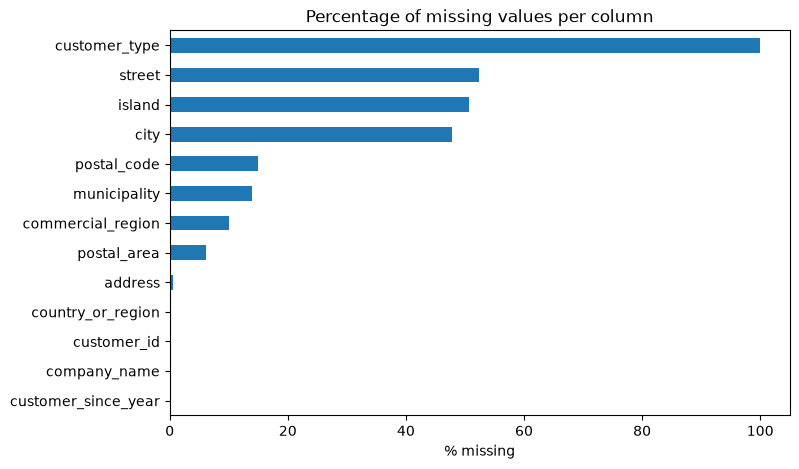

In [18]:
missing["pct_missing"].plot(
    kind="barh",
    figsize=(8, 5),
    title="Percentage of missing values per column",
    xlabel="% missing"
)
plt.gca().invert_yaxis()
plt.show()

`customer_type` is completely empty (100%). `street` (52.3%), `island` (50.6%) and `city` (47.8%) are missing for about half of the customers, `postal_code`, `municipality` and `commercial_region` for 10–15%, while `customer_id`, `country_or_region`, `company_name` and `customer_since_year` are complete.<br>

**Note:** *Missing values do not always mean the same thing. In `island` they are structural (customers from the mainland). In `street` they show no regional pattern within CT10 (it seems to be an optional field left empty because `address` already holds the full address), but they are almost always missing for foreign customers. Customers without `street` also buy again more often, so the fact that the value is missing may itself be useful information.*

### *Structural Missing Values*
*Check whether the missing values depend on other variables (e.g. `island` only filled for CT10 customers) or appear together in the same rows.*

In [19]:
# island filled vs missing per country_or_region
pd.crosstab(
    df["country_or_region"],
    df["island"].isna().map({False: "island filled", True: "island missing"}),
    margins=True
)

island,island filled,island missing,All
country_or_region,,,
Country CT10: Land of The Final Version,565,514,1079
Country CT11: Land of The Final Version,0,1,1
Country CT1: Land of The Final Version,0,1,1
Country CT2: Land of The Final Version,0,1,1
Country CT3: Land of The Final Version,0,1,1
Country CT4: Land of The Final Version,0,4,4
Country CT5: Land of The Final Version,0,49,49
Country CT6: Land of The Final Version,0,3,3
Country CT7: Land of The Final Version,0,2,2


In [20]:
# Percentage of missing values per column within each country_or_region
missing_cols = df.columns[df.isna().any()].drop("customer_type").to_list()
(df[missing_cols].isna().groupby(df["country_or_region"]).mean() * 100).round(1)

,commercial_region,island,municipality,city,postal_area,postal_code,street,address
country_or_region,,,,,,,,
Country CT10: Land of The Final Version,8.8,47.6,8.8,48.0,0.6,15.4,50.0,0.6
Country CT11: Land of The Final Version,0.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0
Country CT1: Land of The Final Version,100.0,100.0,100.0,100.0,100.0,0.0,100.0,0.0
Country CT2: Land of The Final Version,0.0,100.0,100.0,0.0,100.0,0.0,100.0,0.0
Country CT3: Land of The Final Version,100.0,100.0,100.0,0.0,100.0,100.0,100.0,0.0
Country CT4: Land of The Final Version,100.0,100.0,100.0,50.0,100.0,75.0,100.0,0.0
Country CT5: Land of The Final Version,16.3,100.0,100.0,44.9,100.0,0.0,89.8,0.0
Country CT6: Land of The Final Version,33.3,100.0,100.0,0.0,100.0,0.0,66.7,0.0
Country CT7: Land of The Final Version,100.0,100.0,100.0,50.0,100.0,0.0,100.0,0.0


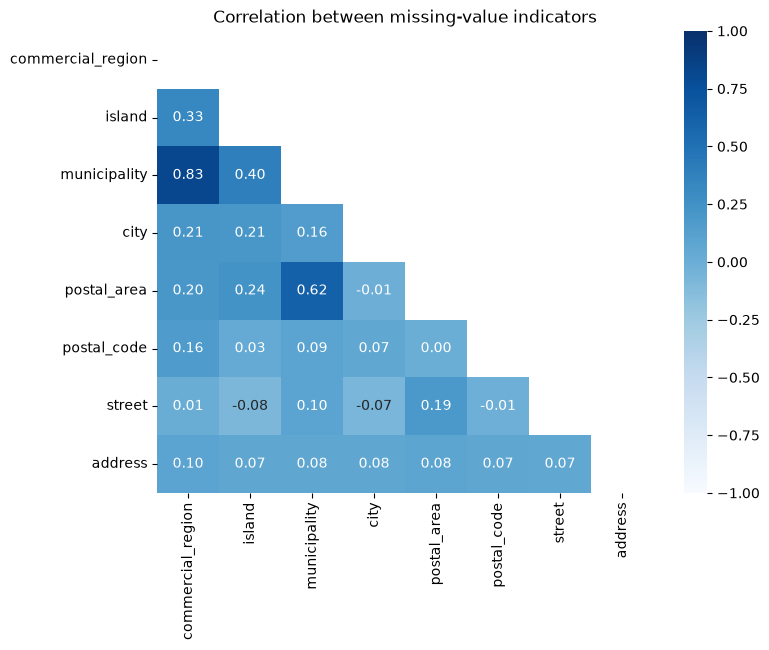

In [21]:
# Do the missing values appear together in the same rows? (correlation between missing-value indicators)
missing_corr = df[missing_cols].isna().astype(int).corr()
# Hide the upper triangle and the diagonal (the matrix is symmetric)
mask = np.triu(np.ones_like(missing_corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(missing_corr, mask=mask, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between missing-value indicators")
plt.show()

In [22]:
# Number of missing values per customer (customer_type excluded)
df[missing_cols].isna().sum(axis=1).value_counts().sort_index().rename_axis("n_missing_in_row").to_frame("n_customers")

,n_customers
n_missing_in_row,
0,121
1,388
2,338
3,135
4,72
5,58
6,24
7,5
8,2


### *Cardinality*
*Number of unique values per column compared with the number of customers, to identify identifier-like variables.*

In [23]:
# Unique values per column compared with the number of customers
cardinality = pd.DataFrame({
    "non_missing": df.notna().sum(),
    "n_unique": df.nunique(),
    "categories_with_one_customer": df.apply(lambda col: (col.value_counts() == 1).sum()),
    "max_customers_per_category": df.apply(lambda col: col.value_counts().max() if col.notna().any() else 0)
})
cardinality["unique_pct_of_non_missing"] = (cardinality["n_unique"] / cardinality["non_missing"] * 100).round(1)
cardinality.sort_values("unique_pct_of_non_missing", ascending=False)

,non_missing,n_unique,categories_with_one_customer,max_customers_per_category,unique_pct_of_non_missing
customer_id,1143,1143,1143,1,100.0
company_name,1143,1141,1139,2,99.8
address,1137,1120,1104,3,98.5
street,545,511,485,5,93.8
postal_code,973,828,721,6,85.1
city,597,417,360,14,69.8
postal_area,1072,271,126,57,25.3
municipality,984,183,65,58,18.6
commercial_region,1029,37,11,519,3.6
island,565,10,0,133,1.8


### *Duplicates*
*Repeated `customer_id` values and repeated `company_name` values.*

In [24]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated rows ignoring customer_id:", df.drop(columns="customer_id").duplicated().sum())
print("Duplicated customer_id:", df["customer_id"].duplicated().sum())
print("Duplicated company_name:", df["company_name"].duplicated().sum())
print("Duplicated address (non-missing):", df["address"].dropna().duplicated().sum())

Fully duplicated rows: 0
Duplicated rows ignoring customer_id: 0
Duplicated customer_id: 0
Duplicated company_name: 2
Duplicated address (non-missing): 17


In [25]:
# Customers that share the same company_name
df[df["company_name"].duplicated(keep=False)].sort_values("company_name")

,customer_id,country_or_region,commercial_region,island,municipality,city,postal_area,postal_code,street,address,customer_type,company_name,customer_since_year
390,255774,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS7: The Pivot Archipelago,Municipality MU12: Council of Last Minute Edits,NaN,Postal area PA254: Hidden Sheet Sector,Postal code PC568: #REF! Delivery Route,NaN,Address AD414: Cell Without a Home,NaN,Excel Is Not A Database Ltd 384,2021
391,714679,Country CT10: Land of The Final Version,Region RG17: We Will See Later,Island IS7: The Pivot Archipelago,Municipality MU12: Council of Last Minute Edits,NaN,Postal area PA254: Hidden Sheet Sector,Postal code PC568: #REF! Delivery Route,NaN,Address AD414: Cell Without a Home,NaN,Excel Is Not A Database Ltd 384,2017
998,652673,Country CT10: Land of The Final Version,Region RG33: We Will See Later,NaN,Municipality MU158: Council of Last Minute Edits,City CY378: Duplicate Row Moor,Postal area PA64: Hidden Sheet Sector,Postal code PC150: #REF! Delivery Route,Street ST427: Merged Cell Place,Address AD975: Cell Without a Home,NaN,Excel Is Not A Database Ltd 664,2015
999,821383,Country CT10: Land of The Final Version,NaN,NaN,NaN,NaN,Postal area PA64: Hidden Sheet Sector,Postal code PC150: #REF! Delivery Route,Street ST470: Relative Reference Rise,Address AD1047: Cell Without a Home,NaN,Excel Is Not A Database Ltd 664,2015


### *Inconsistencies*
*Empty variable (`customer_type`), wrong data types and plausible range of `customer_since_year`.*

In [ ]:
# Data type of each column
df.dtypes.to_frame("dtype")

In [ ]:
# customer_type: data type and number of non-missing values
print("dtype:", df["customer_type"].dtype)
print("Non-missing values:", df["customer_type"].notna().sum(), "of", len(df))

In [ ]:
# customer_since_year: range and values outside the plausible interval (2015 until the current year)
current_year = pd.Timestamp.today().year
print("Min:", df["customer_since_year"].min(), "| Max:", df["customer_since_year"].max())
print("Values outside [2015, current year]:", (~df["customer_since_year"].between(2015, current_year)).sum())

In [ ]:
# customer_since_year vs the first purchase of the same customer in train.csv
train = pd.read_csv("../data/train.csv", usecols=["customer_id", "purchase_date"])
train["customer_id"] = train["customer_id"].astype(str)
first_purchase_year = pd.to_datetime(train["purchase_date"]).dt.year.groupby(train["customer_id"]).min().rename("first_purchase_year")

years = df.set_index("customer_id")[["customer_since_year"]].join(first_purchase_year, how="inner")
print("Customers present in train.csv:", len(years))
print("First purchase before customer_since_year:", (years["first_purchase_year"] < years["customer_since_year"]).sum())

In [ ]:
# Text formatting: leading/trailing spaces and categories that only differ in upper/lower case
text_cols = df.select_dtypes(exclude="number").columns.drop("customer_id")
pd.DataFrame({
    "leading_trailing_spaces": [(df[c].notna() & (df[c].str.strip() != df[c])).sum() for c in text_cols],
    "case_only_differences": [df[c].nunique() - df[c].str.strip().str.lower().nunique() for c in text_cols]
}, index=text_cols)

### *Data Quality Conclusions*
*Summary of the problems found and how they will be handled later.*

## **Univariate Analysis** ##

*Univariate analysis studies one variable at a time to understand its charateristics and distribution*

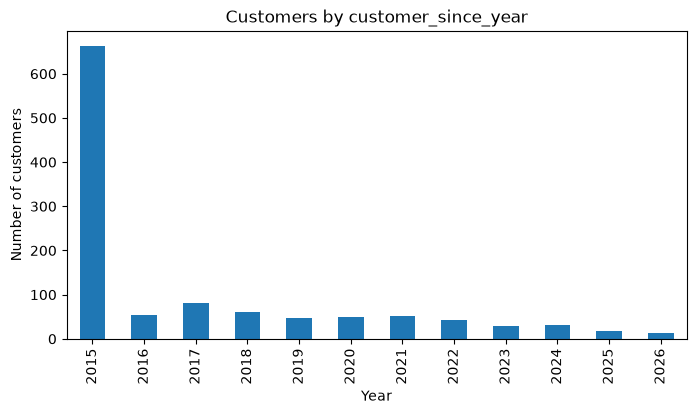

In [17]:
dist = pd.DataFrame({
    "n_customers": df["customer_since_year"].value_counts().sort_index(),
    "pct": (df["customer_since_year"].value_counts(normalize=True).sort_index() * 100).round(1)
})
dist
dist["n_customers"].plot(
    kind="bar",
    figsize=(8, 4),
    title="Customers by customer_since_year",
    xlabel="Year",
    ylabel="Number of customers"
);

In [6]:
# Skewness calculation (Assymetric)
skew_value = df['customer_since_year'].skew()
print(f"Skewness of customer_since_year: {skew_value:.2f}")

if skew_value > 0:
    print("Conclusion: Asymmetrical distribution to the right (right-skewed). Most customers joined long time ago, and the tail extends to the most recent years.")
elif skew_value < 0:
    print("Conclusion: Asymmetrical distribution to the left (left-skewed). Most customers joined in recent years.")
else:
    print("Conclusion: Approximately symmetric distribution.")

Skewness of customer_since_year: 1.36
Conclusion: Asymmetrical distribution to the right (right-skewed). Most customers joined long time ago, and the tail extends to the most recent years.


The mean exceeds the median, so the distribution is right-skewed (most of the values are on the left of the graph, so it's an asymmetrical distribution), as we can see in the graph below. Since the median is more resistant to outliers, they will be very likely to populate the right tail of the distribution.

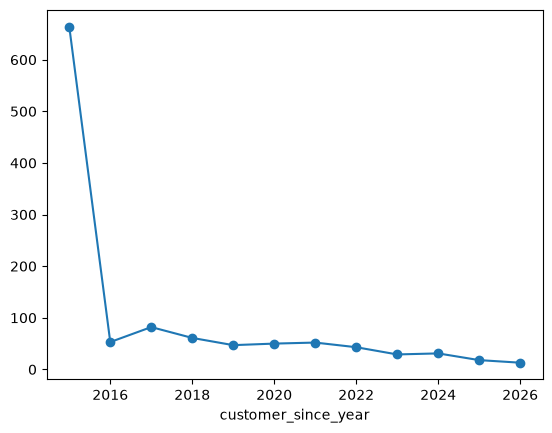

In [18]:
# Line Plot
df['customer_since_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.show()

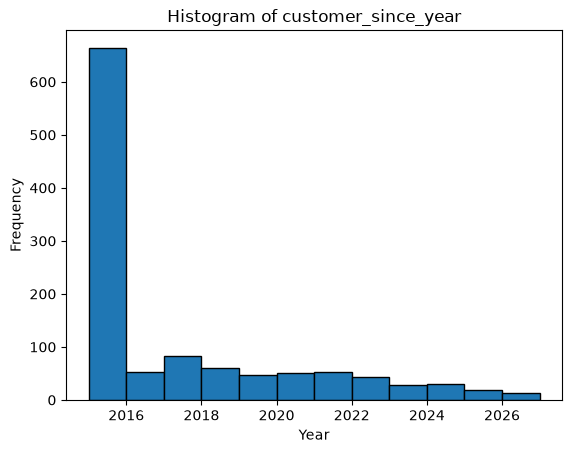

In [11]:
# customer_type is completely empty, so only customer_since_year is plotted
df["customer_since_year"].plot(
    kind="hist",
    bins=range(2015, 2028),
    edgecolor="black",
    title="Histogram of customer_since_year"
)
plt.xlabel("Year")
plt.show()

Dominant category in 'country_or_region': Country CT10: Land of The Final Version with 94.4% of clients.


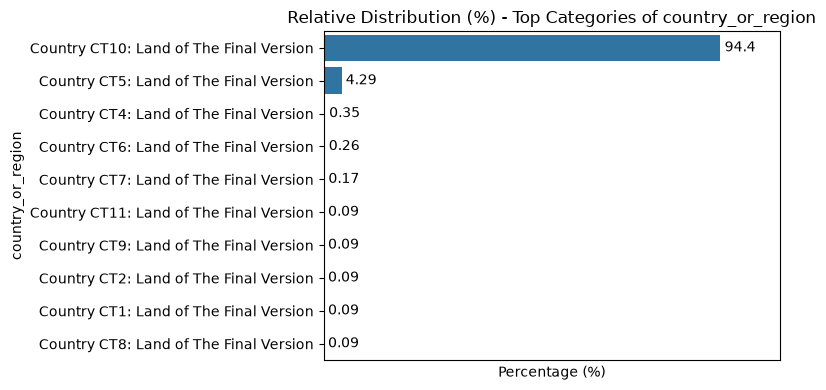

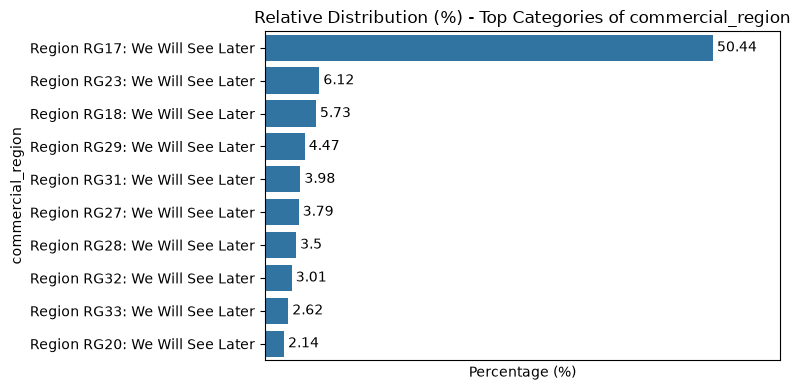

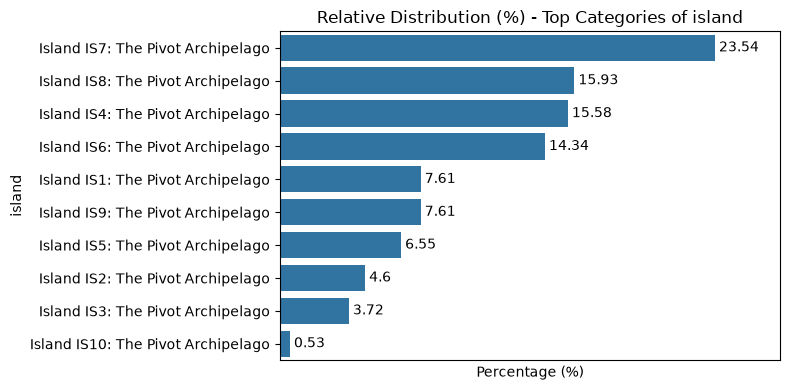

In [51]:
# Highlighting the inbalance of country_or_region(CT10)
country_counts = df['country_or_region'].value_counts(normalize=True) * 100
top_country = country_counts.index[0]
top_country_pct = country_counts.iloc[0]

print(f"Dominant category in 'country_or_region': {top_country} with {top_country_pct:.1f}% of clients.")

# Relative freq graph (%) for low cardinality
for col in ['country_or_region', 'commercial_region', 'island']:
    plt.figure(figsize=(8, 4))
    
    pcts = (df[col].value_counts(normalize=True).head(10) * 100).round(2)
    
    ax = sns.barplot(
        x=pcts.values,
        y=pcts.index,
        legend=False
    )
    
    # Add labels with the exact count at the end of each bar  
    for container in ax.containers:
        ax.bar_label(container, padding=3)
            
    #Remove the x-axis 
    plt.xticks([])
    plt.title(f"Relative Distribution (%) - Top Categories of {col}")
    plt.xlabel("Percentage (%)")
    plt.ylabel(col)
    plt.xlim(0, max(pcts.values) * 1.15)
    plt.tight_layout()
    plt.show()

• Total of unique categories: 183
• Categories with only one client: 65 (35.5% of total categories)


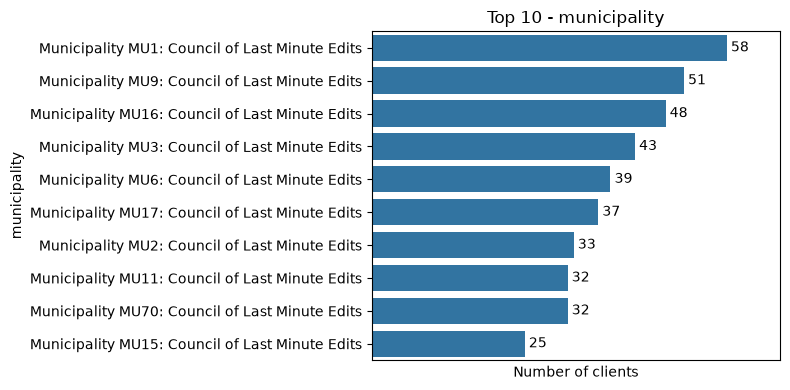

• Total of unique categories: 417
• Categories with only one client: 360 (86.3% of total categories)


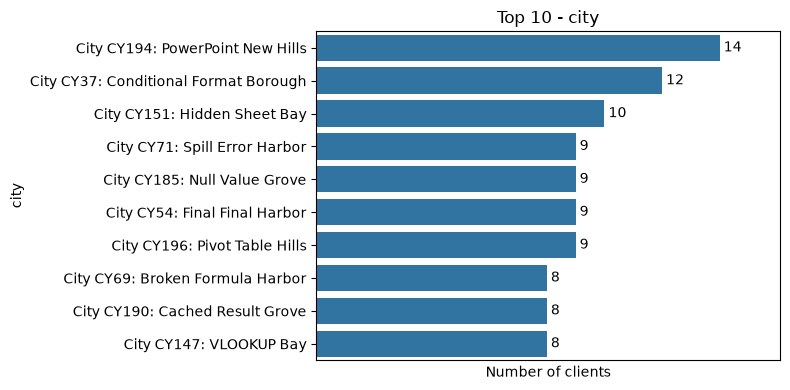

• Total of unique categories: 828
• Categories with only one client: 721 (87.1% of total categories)


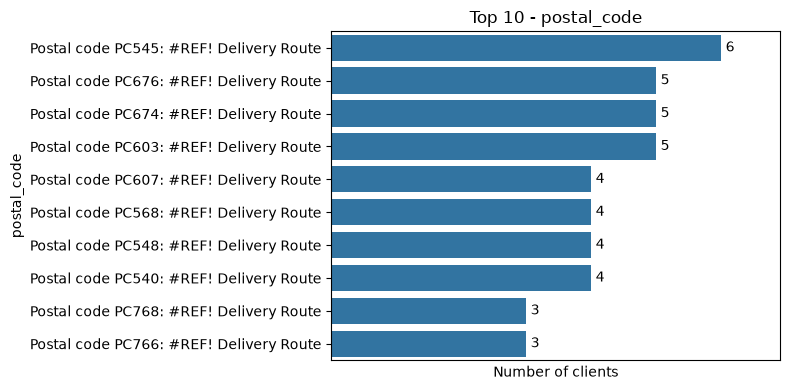

In [54]:
high_card_cols = ['municipality', 'city', 'postal_code']

for col in high_card_cols:
    if col in df.columns:
        counts = df[col].value_counts()
        total_categories = df[col].nunique()
        single_occurrence = (counts == 1).sum()
        pct_single = (single_occurrence / total_categories) * 100
        
        print(f"• Total of unique categories: {total_categories}")
        print(f"• Categories with only one client: {single_occurrence} ({pct_single:.1f}% of total categories)")
        
        # Graph only from the Top 10
        plt.figure(figsize=(8, 4))
        top10 = counts.head(10)
        
        ax = sns.barplot(
            x=top10.values,
            y=top10.index,
            legend=False
        )
        
        # Add labels with the exact count at the end of each bar  
        for container in ax.containers:
            ax.bar_label(container, padding=3)
        
        #Remove the X-axis 
        plt.xticks([])
        plt.title(f"Top 10 - {col}")
        plt.xlabel("Number of clients")
        plt.ylabel(col)
        plt.xlim(0, max(top10.values) * 1.15)
        plt.tight_layout()
        plt.show()

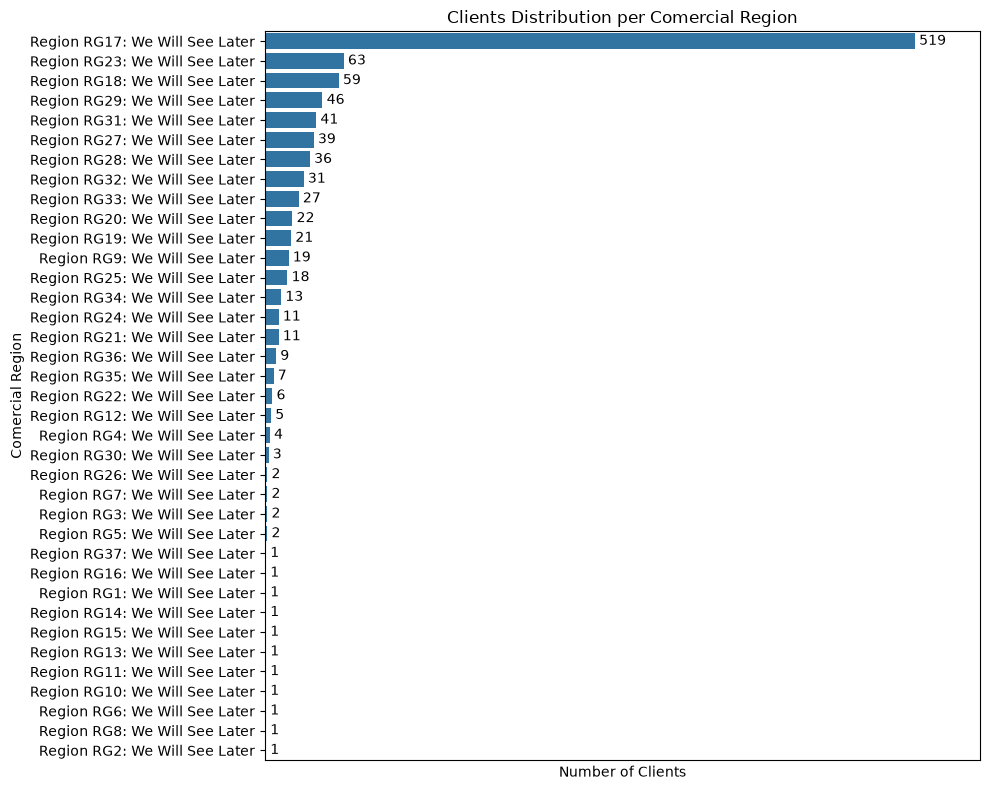

In [21]:
# For Comercial Regions 
plt.figure(figsize=(10, 8))

# Filter only the regions with at least 1 client (> 0)
counts = df['commercial_region'].value_counts()
active_regions = counts[counts > 0].index

# Draw the graph
ax = sns.countplot(
    data=df,
    y='commercial_region',
    order=active_regions
)

# Add the label with the exact count at the end of each bar
ax.bar_label(ax.containers[0], padding=3)

# Adjusts the X-axis limit so the numbers don't get cut off at the margin  
plt.xlim(0, counts.max() * 1.1)

# Remove the X-axis count
plt.xticks([])

plt.title('Clients Distribution per Comercial Region')
plt.xlabel('Number of Clients')
plt.ylabel('Comercial Region')

plt.tight_layout()
plt.show()


 ## **Bivariate Analysis** ## 

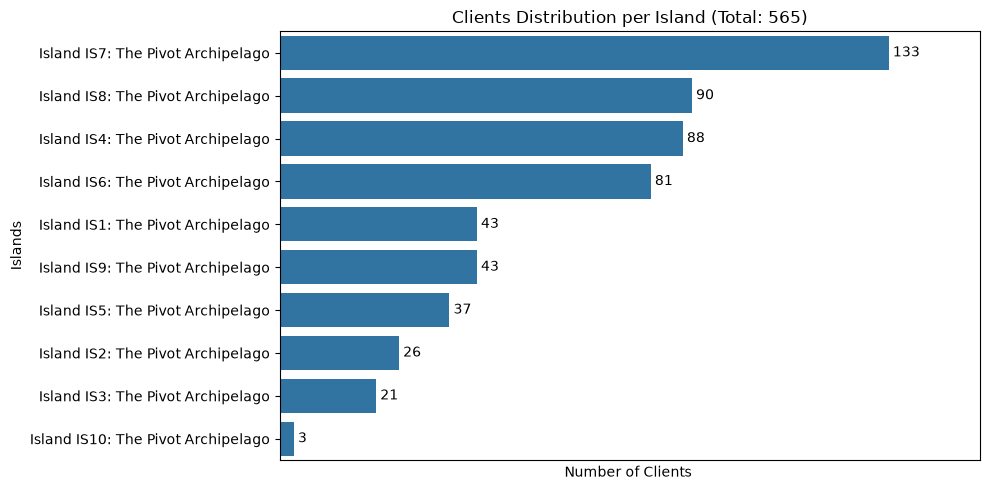

In [20]:
# For the islands(to analyse the 565 clients from the islands)
plt.figure(figsize=(10, 5))

# Filter only the islands with at least 1 client(> 0)
counts_island = df['island'].value_counts()
active_islands = counts_island[counts_island > 0].index

# Draw the horizontal bar chart (y='island')
ax = sns.countplot(
    data=df,
    y='island',
    order=active_islands
)

# Add labels with the exact count at the end of each bar  
ax.bar_label(ax.containers[0], padding=3)

# Adjust the limit of the X-axis  limit to leave space for the label numbers
plt.xlim(0, counts_island.max() * 1.15)

# Remove the number in the X-axis (below)
plt.xticks([])

plt.title("Clients Distribution per Island (Total: 565)")
plt.xlabel("Number of Clients ")
plt.ylabel("Islands")

plt.tight_layout()
plt.show()

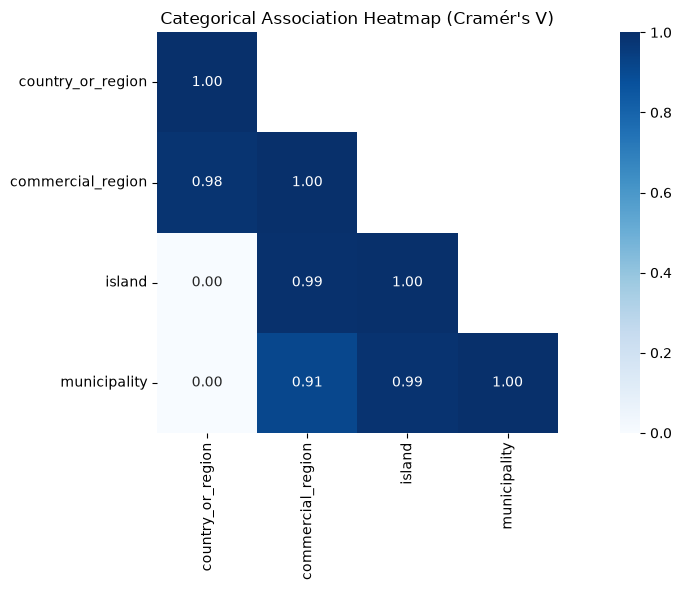

In [76]:
geo_cols = ['country_or_region', 'commercial_region', 'island', 'municipality']

matrix_v = pd.DataFrame(np.nan, index=geo_cols, columns=geo_cols)

for c in geo_cols:
    matrix_v.loc[c, c] = 1.0  # diagonal

# Lower triangle only: each pair is computed once (Cramér's V is symmetric)
for i, c1 in enumerate(geo_cols):
    for c2 in geo_cols[i + 1:]:
        pair = df[[c1, c2]].dropna()
        matrix_v.loc[c2, c1] = cramers_v(pair[c1], pair[c2])

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_v, annot=True, fmt='.2f',
            cmap='Blues', vmin=0, vmax=1, square=True,
            cbar_kws={'pad': 0.1})
plt.title("Categorical Association Heatmap (Cramér's V)")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Geographic Hierarchy and Redundancy

The Cramér's V heatmap shows very strong associations among `commercial_region`, `island` and `municipality` (0.91 to 0.99). This is expected: the geographic variables are strictly nested, and the structural check confirms that each municipality belongs to exactly one commercial region.

`country_or_region` behaves differently. It is almost perfectly associated with `commercial_region` (0.98), but shows no association with `island` or `municipality` (0.00). This is a class-imbalance effect: a single category (CT10) accounts for 94.4% of records, so there is almost no variation left to associate with the lower tiers.

**Implication:** these features are largely redundant and would introduce severe categorical multicollinearity. We keep a single level of the hierarchy for predictive modelling.

In [50]:
df['country_or_region'].value_counts(normalize=True).head()


country_or_region
Country CT10: Land of The Final Version    0.944007
Country CT5: Land of The Final Version     0.042870
Country CT4: Land of The Final Version     0.003500
Country CT6: Land of The Final Version     0.002625
Country CT7: Land of The Final Version     0.001750
Name: proportion, dtype: float64

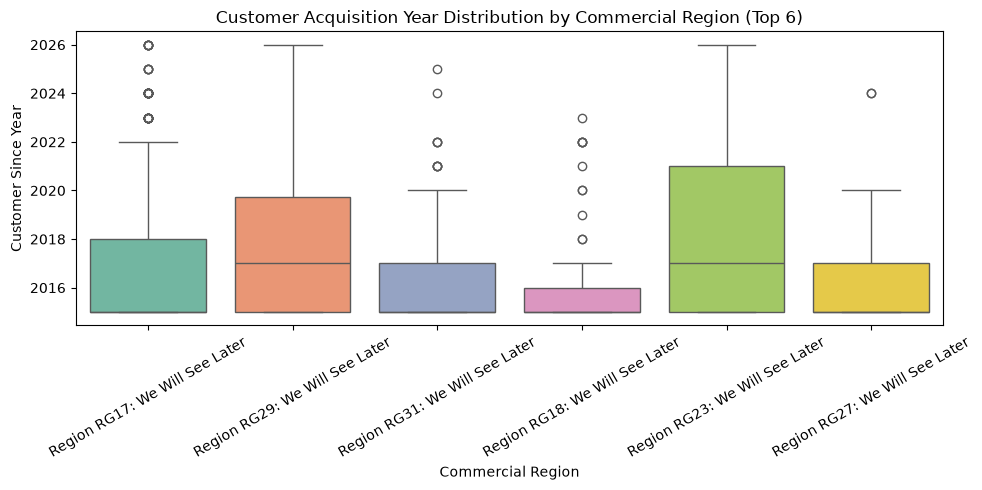

In [15]:
plt.figure(figsize=(10, 5))

# Select the top comercial regions for readability
top_reg = df['commercial_region'].value_counts().head(6).index
df_top_reg = df[df['commercial_region'].isin(top_reg)]

sns.boxplot(
    data=df_top_reg,
    x='commercial_region',
    y='customer_since_year',
    hue='commercial_region',
    palette='Set2',
    legend=False
)

plt.title("Customer Acquisition Year Distribution by Commercial Region (Top 6)")
plt.xlabel("Commercial Region")
plt.ylabel("Customer Since Year")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Temporal Distribution across Commercial Regions

Across the top six commercial regions, the median acquisition year is similar, between 2015 and 2017, so most regions share the same historical baseline. The differences are in the spread:

- **Concentrated, older base (RG18, RG31):** narrow interquartile range, with only a few recent customers appearing as outliers.
- **Wider spread, more recent acquisition (RG23, RG29):** the upper quartile and whiskers extend towards 2020–2026, so these regions kept acquiring customers for longer.
- **Mixed (RG17, RG27):** a compact core around 2015–2018, with some recent outliers.

Overall, regions differ less in *when* they started than in *how long* they kept growing.

## **Multivariate Analysis** ##